In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
variables=pd.read_excel('RDZ_variables.xlsx')
reer=pd.read_csv('reer_norway.csv')
exped=pd.read_excel('exped.xlsx')

In [ ]:
variables=variables.rename(columns={'Дата':'Date','Изменения объема расходов бюджета правительства (%)':'diff_in_exped', 'Цена на нефть марки Brent(Долларов за баррель)':'brent', 'Валовой долг органов государственного управления (в процентах от ВВП)':'gov_debt', 'Темпы роста реального ВВП (%)':'growth'})

In [ ]:
variables['Date']=pd.to_datetime(variables['Date'], format='%Y').dt.year

In [ ]:
reer['Date']=pd.to_datetime(reer['Date'], format='%Y').dt.year

In [ ]:
exped['Date']=pd.to_datetime(exped['Date'], format='%Y').dt.year

In [ ]:
variables=variables.drop('diff_in_exped', axis=1)

In [ ]:
variables=variables.merge(exped, on='Date')

In [ ]:
variables=variables.merge(reer, on='Date')

In [ ]:
variables['fiscal_rule']=None

In [ ]:
variables.loc[variables['Date']<2001, 'fiscal_rule']=0
variables.loc[variables['Date']>=2001, 'fiscal_rule']=1

In [ ]:
variables['fiscal_rule']=variables['fiscal_rule'].apply(pd.to_numeric)

In [ ]:
X=variables.drop(['Date', 'exped'], axis=1)

In [ ]:
Y=variables['exped']

In [ ]:
variables.dtypes

,0
Date,int32
brent,float64
gov_debt,float64
growth,float64
exped,int64
REER_value,float64
fiscal_rule,int64


In [ ]:
X=sm.add_constant(X)

In [ ]:
model=sm.OLS(Y, X)

In [ ]:
results=model.fit()

In [ ]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  exped   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     92.63
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           6.92e-15
Time:                        19:17:56   Log-Likelihood:                -374.11
No. Observations:                  30   AIC:                             760.2
Df Residuals:                      24   BIC:                             768.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        2.516e+06   1.71e+05     14.739      

In [ ]:
X_before=variables.loc[variables['Date']<2001].drop(['Date', 'exped'], axis=1)
Y_before=variables.loc[variables['Date']<2001, 'exped']

In [ ]:
X_after=variables.loc[variables['Date']>=2001].drop(['Date', 'exped'], axis=1)
Y_after=variables.loc[variables['Date']>=2001, 'exped']

In [ ]:
X_before=sm.add_constant(X_before, has_constant='add')
X_after=sm.add_constant(X_after, has_constant='add')

In [ ]:
model_before=sm.OLS(Y_before, X_before).fit()
model_after=sm.OLS(Y_after, X_after).fit()

In [ ]:
RSS_U=np.sum(results.resid**2)

In [ ]:
RSS_R1=np.sum(model_before.resid**2)
RSS_R2=np.sum(model_before.resid**2)

In [ ]:
F_chow=((RSS_U-(RSS_R1+RSS_R2))/6)/((RSS_R1+RSS_R2)/(30-12))

In [ ]:
F_chow

np.float64(789.4758544783851)

In [ ]:
REER_list=[73.7*(11.8/11.9), 73.7*(11.8/12.1), 73.7*(11.8/12.3), 73.7*(11.8/12.4)] #Здесь REER рассчитывается грубой аппроксимацией через использование обменного курса евро и норвежской кроны, т.к. это наиболее быстрый способ посчитать параметр, в том числе потому что евро имеет очень большой вес в корзине. Конкретно здесь расчет такой: REER_t=REER_base*(E_base/E_t), где E - обменный курс, base - базовый код, в данном случае 2024

In [ ]:
variables_forecast=pd.DataFrame({'Date':[2025, 2026, 2027, 2028], 'brent':[61.5, 56.4, 54.6, 49.6], 'gov_debt':[42.5, 41.1, 39.8, 38.4], 'growth': [1.7, 1.5, 2.1, 1.9], 'REER_value': REER_list, 'fiscal_rule':[1, 1, 1, 1]})

In [ ]:
variables_forecast['Date']=pd.to_datetime(variables_forecast['Date'], format='%Y').dt.year

In [ ]:
variables_forecast['fiscal_rule']=variables_forecast['fiscal_rule'].apply(pd.to_numeric)

In [ ]:
variables_forecast['Date'].dtype

dtype('int32')

In [ ]:
X_forecast

,const,brent,gov_debt,growth,REER_value,fiscal_rule
0,1.0,61.5,42.5,1.7,73.080672,1
1,1.0,56.4,41.1,1.5,71.872727,1
2,1.0,54.6,39.8,2.1,70.704065,1
3,1.0,49.6,38.4,1.9,70.133871,1


In [ ]:
X_forecast=variables_forecast.drop('Date', axis=1)

In [ ]:
X_forecast=sm.add_constant(X_forecast, has_constant='add')

In [ ]:
y_pred=results.predict(X_forecast)

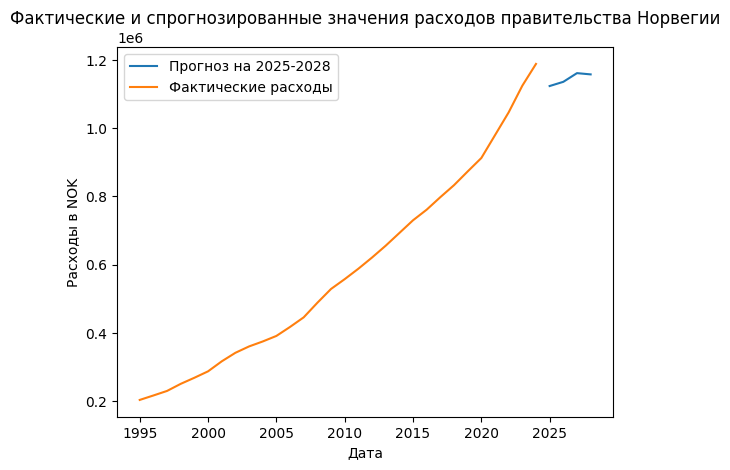

In [ ]:
plt.plot(variables_forecast['Date'], y_pred, label='Прогноз на 2025-2028')
plt.plot(variables['Date'], variables['exped'], label='Фактические расходы')
plt.title('Фактические и спрогнозированные значения расходов правительства Норвегии')
plt.ylabel('Расходы в NOK')
plt.xlabel('Дата')
plt.legend()
plt.savefig('Прогноз по расходам.png', bbox_inches='tight')